# Path Progression on a Track Graph (Bandit Task Real Data)

This notebook demonstrates **goal-to-goal trial segmentation and path
progression analysis** on a real hippocampal recording from the same
bandit-task dataset used in `19_real_data_bandit_task.ipynb`.

**Dataset**: J16 session, 2021-07-10 (triple-Y maze, 3 reward patches,
6 well endpoints, 24 minutes of position tracking at 500 Hz).

**What you'll learn**

- How to define goal regions from a track graph's endpoint nodes
- How to detect well-entry events and pair them into goal-to-goal trials
- How to compute normalized path progress (0 -> 1) along the track graph
- How to visualize per-trial and aggregate progression

**Pipeline**

```
track graph + positions
        |
        v
 Environment.from_graph (1D linearized, but still queryable in 2D)
        |
        v
 env.regions.buffer(...)  for each endpoint = well region
        |
        v
 detect_region_crossings(direction="entry")  for each well
        |
        v
 pair consecutive visits -> trials
        |
        v
 path_progress(metric="geodesic")
```

In [2]:
import importlib.util
import itertools
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from neurospatial import Environment
from neurospatial.behavior import path_progress
from neurospatial.behavior.segmentation import detect_region_crossings


def _find_project_root(start: Path) -> Path:
    """Find the project root containing the real-data helper."""
    for path in (start, *start.parents):
        if (path / "data" / "load_bandit_data.py").exists():
            return path
    raise FileNotFoundError(f"Could not find data/load_bandit_data.py from {start}")


try:
    _start_path = Path(__file__).resolve().parent
except NameError:
    _start_path = Path.cwd().resolve()
_base_path = _find_project_root(_start_path)

_loader_spec = importlib.util.spec_from_file_location(
    "load_bandit_data", _base_path / "data" / "load_bandit_data.py"
)
if _loader_spec is None or _loader_spec.loader is None:
    raise ImportError("Could not load bandit data helper")
_loader_module = importlib.util.module_from_spec(_loader_spec)
_loader_spec.loader.exec_module(_loader_module)
load_neural_recording_from_files = _loader_module.load_neural_recording_from_files

# Shared styling (Okabe-Ito palette, consistent figure / font sizes)
import sys  # noqa: E402

_here = (
    str(Path(__file__).resolve().parent) if "__file__" in globals() else str(Path.cwd())
)
if _here not in sys.path:
    sys.path.insert(0, _here)
from _style import apply_style  # noqa: E402

apply_style(figsize=(12, 8), font_size=11)

## 1. Load the bandit-task recording

We only need the position trace and the track graph for this notebook;
spike data is ignored.

In [3]:
data = load_neural_recording_from_files(_base_path / "data", "j1620210710_02_r1")
position_info = data["position_info"]
track_graph = data["track_graph"]
linear_edge_order = data["linear_edge_order"]
linear_edge_spacing = data["linear_edge_spacing"]

times = position_info.index.values
positions = position_info[["head_position_x", "head_position_y"]].values

duration = times[-1] - times[0]
print(f"Recording: {len(times):,} samples, {duration / 60:.1f} min")
print(
    f"Track graph: {track_graph.number_of_nodes()} nodes, "
    f"{track_graph.number_of_edges()} edges"
)

Recording: 709,321 samples, 23.6 min
Track graph: 10 nodes, 9 edges


## 2. Build the environment from the track graph

`Environment.from_graph` creates a 1D linearized environment whose bins
live along the track. The env is still queryable with 2D points
(`env.bin_at(positions_2d)`) -- coordinates are snapped to the nearest
track segment.

In [4]:
env = Environment.from_graph(
    graph=track_graph,
    edge_order=linear_edge_order,
    edge_spacing=linear_edge_spacing,
    bin_size=2.0,
    name="bandit_track",
)
env.units = "cm"

print(f"Environment: {env.n_bins} bins along the linearized track")
print(f"is_linearized_track: {env.is_linearized_track}")

Environment: 248 bins along the linearized track
is_linearized_track: True


## 3. Define the wells as goal regions

The maze is a triple-Y (3 arms x 2 wells per arm = 6 wells). The 6 wells
correspond to the **endpoint nodes** of the track graph (those with
degree 1). For each endpoint we create a small buffered polygon
region; `path_progress`'s segmentation step needs polygons, since point
regions have zero area and `regions_to_mask` would return empty masks.

In [5]:
endpoint_nodes = sorted(n for n in track_graph.nodes if track_graph.degree(n) == 1)
well_radius_cm = 8.0
well_names: list[str] = []
for n in endpoint_nodes:
    name = f"well_{n}"
    env.regions.buffer(
        np.asarray(track_graph.nodes[n]["pos"], dtype=float),
        well_radius_cm,
        name,
    )
    well_names.append(name)

print(f"Defined {len(well_names)} wells (radius={well_radius_cm} cm):")
for w in well_names:
    bins = env.bins_in_region(w)
    print(f"  {w}: {len(bins)} track bins")

Defined 6 wells (radius=8.0 cm):
  well_0: 4 track bins
  well_1: 4 track bins
  well_2: 4 track bins
  well_3: 4 track bins
  well_4: 4 track bins
  well_5: 4 track bins


Plot the maze with wells highlighted to confirm the regions land on the
track endpoints.

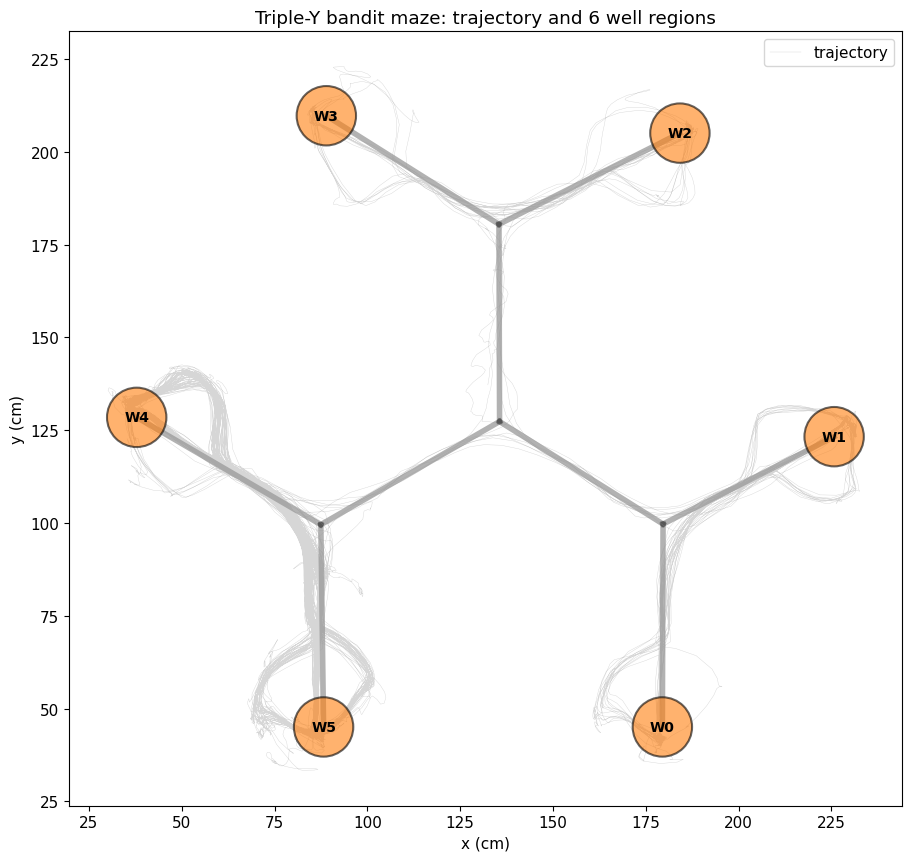

In [6]:
fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)

# Track edges
for u, v in track_graph.edges():
    pu = np.array(track_graph.nodes[u]["pos"])
    pv = np.array(track_graph.nodes[v]["pos"])
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], "k-", lw=4, alpha=0.3, zorder=1)

# Trajectory (subsampled)
ax.plot(
    positions[::40, 0],
    positions[::40, 1],
    color="0.6",
    lw=0.3,
    alpha=0.4,
    zorder=2,
    label="trajectory",
)

# Well regions (drawn as circles at the endpoint node positions, matching
# the buffer radius used to build the region polygons).
for n, w in zip(endpoint_nodes, well_names, strict=True):
    cx, cy = track_graph.nodes[n]["pos"]
    ax.add_patch(
        Circle(
            (cx, cy),
            well_radius_cm,
            facecolor="tab:orange",
            edgecolor="black",
            lw=1.5,
            alpha=0.6,
            zorder=5,
        )
    )
    ax.annotate(
        w.replace("well_", "W"),
        (cx, cy),
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=6,
    )

ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_title("Triple-Y bandit maze: trajectory and 6 well regions")
ax.legend(loc="upper right")
plt.show()

## 4. Detect well-entry events

`detect_region_crossings(..., direction="entry")` returns the first
sample inside each region per visit. We collect entries from every well
and merge them chronologically into one visit list.

In [7]:
position_bins = env.bin_at(positions)

visits: list[tuple[float, str, int]] = []
for w in well_names:
    for cr in detect_region_crossings(
        position_bins, times, env, region_name=w, direction="entry"
    ):
        visits.append((cr.time, w, int(cr.bin_index)))
visits.sort(key=lambda v: v[0])

print(f"Total well-entry events: {len(visits)}")
print("Visits per well:")
for w, n in Counter(v[1] for v in visits).most_common():
    print(f"  {w}: {n}")

Total well bouts: 191
Bouts per well:
  well_4: 70
  well_5: 66
  well_1: 18
  well_0: 15
  well_2: 13
  well_3: 9


## 5. Pair consecutive visits into goal-to-goal trials

Trial `i` = from visit `i` to visit `i+1`:
- `t0 = visit_i.time` (animal enters well A)
- `t1 = visit_{i+1}.time` (animal enters well B)
- `start_bin = A's entry bin`, `goal_bin = B's entry bin`

Self-transitions (consecutive entries to the same well, usually a brief
excursion and re-entry) are dropped.

**Interpretation note.** With this convention each trial spans the full
epoch from "animal arrived at A" to "animal arrived at B". For long
trials the animal often sits at A for several seconds (consuming
reward, sniffing the patch) before committing to the travel; during
that period `path_progress` correctly reports a value near 0, because
the animal hasn't actually moved toward B yet. The per-trial curves in
section 8 will show this as a flat segment followed by a ramp -- that's
real behaviour, not a bug.

In [8]:
trials = []
for (t0, a, ba), (t1, b, bb) in itertools.pairwise(visits):
    if a == b:
        continue
    trials.append(
        {"t0": t0, "t1": t1, "start": a, "goal": b, "start_bin": ba, "goal_bin": bb}
    )

durations = np.array([tr["t1"] - tr["t0"] for tr in trials])
print(f"Trials: {len(trials)}  (after dropping self-transitions)")
print(
    f"Duration (s): min={durations.min():.2f}  "
    f"median={np.median(durations):.2f}  max={durations.max():.2f}"
)

# Transition matrix (start well -> goal well counts)
labels = well_names
idx = {w: i for i, w in enumerate(labels)}
M = np.zeros((len(labels), len(labels)), dtype=int)
for tr in trials:
    M[idx[tr["start"]], idx[tr["goal"]]] += 1

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(M, cmap="viridis")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels([w.replace("well_", "W") for w in labels])
ax.set_yticklabels([w.replace("well_", "W") for w in labels])
ax.set_xlabel("goal well")
ax.set_ylabel("start well")
ax.set_title("Transition counts (start -> goal)")
for i in range(len(labels)):
    for j in range(len(labels)):
        if M[i, j]:
            ax.text(
                j,
                i,
                M[i, j],
                ha="center",
                va="center",
                color="white" if M[i, j] < M.max() / 2 else "black",
                fontsize=10,
            )
plt.colorbar(im, ax=ax, label="n trials")
plt.show()

[(1625935762.2108786, 1625935769.1908762, 'well_2', 131),
 (1625935773.7528746, 1625935780.2448723, 'well_3', 159),
 (1625935782.1428716, 1625935785.0488706, 'well_2', 131),
 (1625935785.2828705, 1625935785.4088705, 'well_2', 131),
 (1625935789.2188692, 1625935799.2488656, 'well_1', 76),
 (1625935801.014865, 1625935810.6168616, 'well_0', 50),
 (1625935812.3868608, 1625935821.6208577, 'well_1', 76),
 (1625935823.330857, 1625935826.1428561, 'well_0', 50),
 (1625935827.8708553, 1625935829.8928547, 'well_1', 76),
 (1625935833.6028533, 1625935841.7948503, 'well_4', 216),
 (1625935843.7268498, 1625935861.3708434, 'well_5', 244),
 (1625935863.4548428, 1625935871.48684, 'well_4', 216),
 (1625935873.3708394, 1625935875.4168386, 'well_5', 244),
 (1625935877.4208379, 1625935886.6468346, 'well_4', 216),
 (1625935888.590834, 1625935896.1588311, 'well_5', 244),
 (1625935897.9068305, 1625935905.7028277, 'well_4', 216),
 (1625935907.776827, 1625935909.2988265, 'well_5', 244),
 (1625935911.4088259, 162

## 6. Compute path progression

Build per-timepoint `start_bins` / `goal_bins` arrays from the trial
list, then call `path_progress`. A **half-open mask** `[t0, t1)` keeps
adjacent trials from overwriting each other's boundary timestamp (the
entry into well B is the *end* of trial A->B and the *start* of trial
B->C, but each timepoint can belong to only one trial).

`metric="geodesic"` is essential on a track graph: it measures distance
along the connectivity graph, so going from one arm to another correctly
routes through the centre node instead of cutting across the linearized
gaps between arms.

In [10]:
start_bins = np.full(len(times), -1, dtype=np.int_)
goal_bins = np.full(len(times), -1, dtype=np.int_)
for tr in trials:
    mask = (times >= tr["t0"]) & (times < tr["t1"])
    start_bins[mask] = tr["start_bin"]
    goal_bins[mask] = tr["goal_bin"]

progress = path_progress(
    position_bins,
    env,
    start_bins=start_bins,
    goal_bins=goal_bins,
    metric="geodesic",
)
print(f"progress range: [{np.nanmin(progress):.3f}, {np.nanmax(progress):.3f}]")
print(f"timepoints inside a trial: {(~np.isnan(progress)).sum():,} / {len(progress):,}")

progress range: [0.009, 0.991]
timepoints inside a trial: 217,735 / 709,321


## 7. Linear position and path progression over the session

Stacked time-series view: linear position along the track on top, path
progression on bottom (shared x-axis). Each trial appears as a 0 -> 1
ramp in the bottom row; the corresponding linear-position trace shows
the actual arm the animal traversed during that ramp. Gaps in the
progression trace are timepoints outside any trial (NaN).

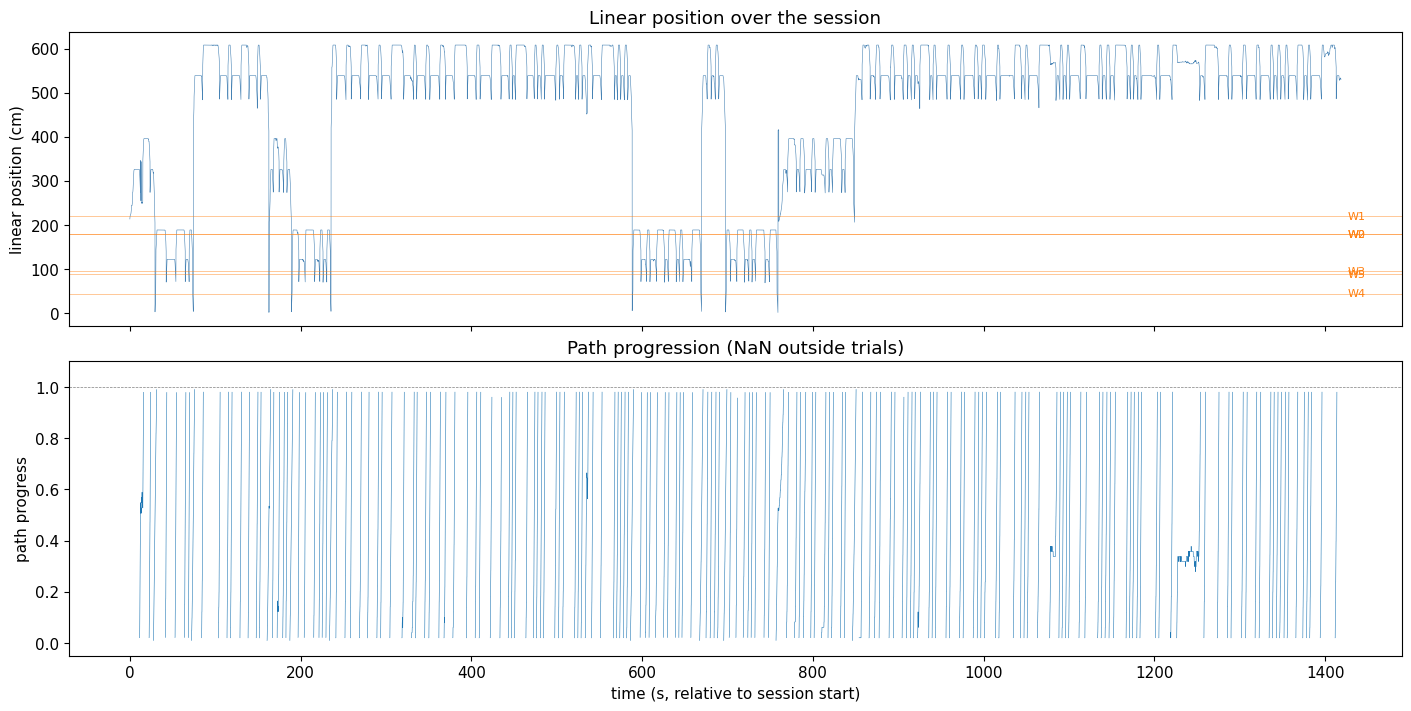

In [11]:
linear_pos = position_info["linear_position"].values
t_rel = times - times[0]

# Subsample for plotting speed without dropping trial structure (~30 Hz).
SUB = 17
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(t_rel[::SUB], linear_pos[::SUB], color="steelblue", lw=0.4)
# Mark each well's linear coordinate so it's easy to see which arm the
# animal is on at any time.
for w in well_names:
    well_bins = env.bins_in_region(w)
    if len(well_bins) == 0:
        continue
    # Bin centres for graph envs are 1-D linear coordinates.
    y = float(env.bin_centers[well_bins[0], 0])
    ax.axhline(y, color="tab:orange", lw=0.6, alpha=0.5)
    ax.text(
        t_rel[-1] * 1.005,
        y,
        w.replace("well_", "W"),
        fontsize=8,
        va="center",
        color="tab:orange",
    )
ax.set_ylabel("linear position (cm)")
ax.set_title("Linear position over the session")

ax = axes[1]
ax.plot(t_rel[::SUB], progress[::SUB], color="tab:blue", lw=0.4)
ax.axhline(1.0, color="tab:gray", lw=0.5, ls="--")
ax.set_xlabel("time (s, relative to session start)")
ax.set_ylabel("path progress")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Path progression (NaN outside trials)")

plt.show()

Same two rows zoomed to a ~3-minute window so individual trials are
resolvable -- each ramp on the bottom row should align with a sweep
across linear-position values on the top row.

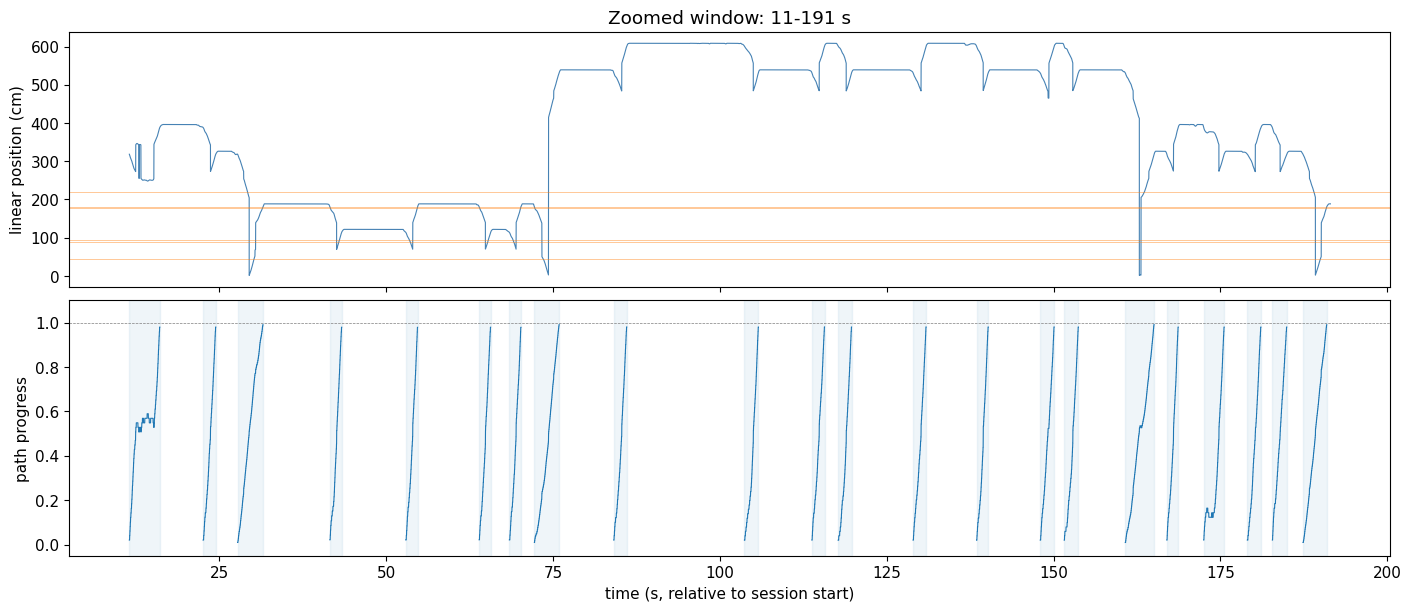

In [12]:
zoom_start = float(trials[0]["t0"] - times[0])
zoom_end = zoom_start + 180.0  # 3-minute window
zoom_mask = (t_rel >= zoom_start) & (t_rel <= zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(t_rel[zoom_mask], linear_pos[zoom_mask], color="steelblue", lw=0.8)
for w in well_names:
    well_bins = env.bins_in_region(w)
    if len(well_bins) == 0:
        continue
    y = float(env.bin_centers[well_bins[0], 0])
    ax.axhline(y, color="tab:orange", lw=0.6, alpha=0.5)
ax.set_ylabel("linear position (cm)")
ax.set_title(f"Zoomed window: {zoom_start:.0f}-{zoom_end:.0f} s")

ax = axes[1]
ax.plot(t_rel[zoom_mask], progress[zoom_mask], color="tab:blue", lw=0.8)
# Shade each trial in the window for visual reference.
for tr in trials:
    t0r = tr["t0"] - times[0]
    t1r = tr["t1"] - times[0]
    if t1r < zoom_start or t0r > zoom_end:
        continue
    ax.axvspan(t0r, t1r, color="tab:blue", alpha=0.07)
ax.axhline(1.0, color="tab:gray", lw=0.5, ls="--")
ax.set_xlabel("time (s, relative to session start)")
ax.set_ylabel("path progress")
ax.set_ylim(-0.05, 1.1)

plt.show()

## 8. Per-trial progress curves

Plot the first nine trials' progress over time. A clean goal-directed
run shows a near-monotonic rise from 0 to ~1. Plateaus near 0 indicate
the animal lingering at the start well; non-monotonic dips mean the
animal looped back partway.

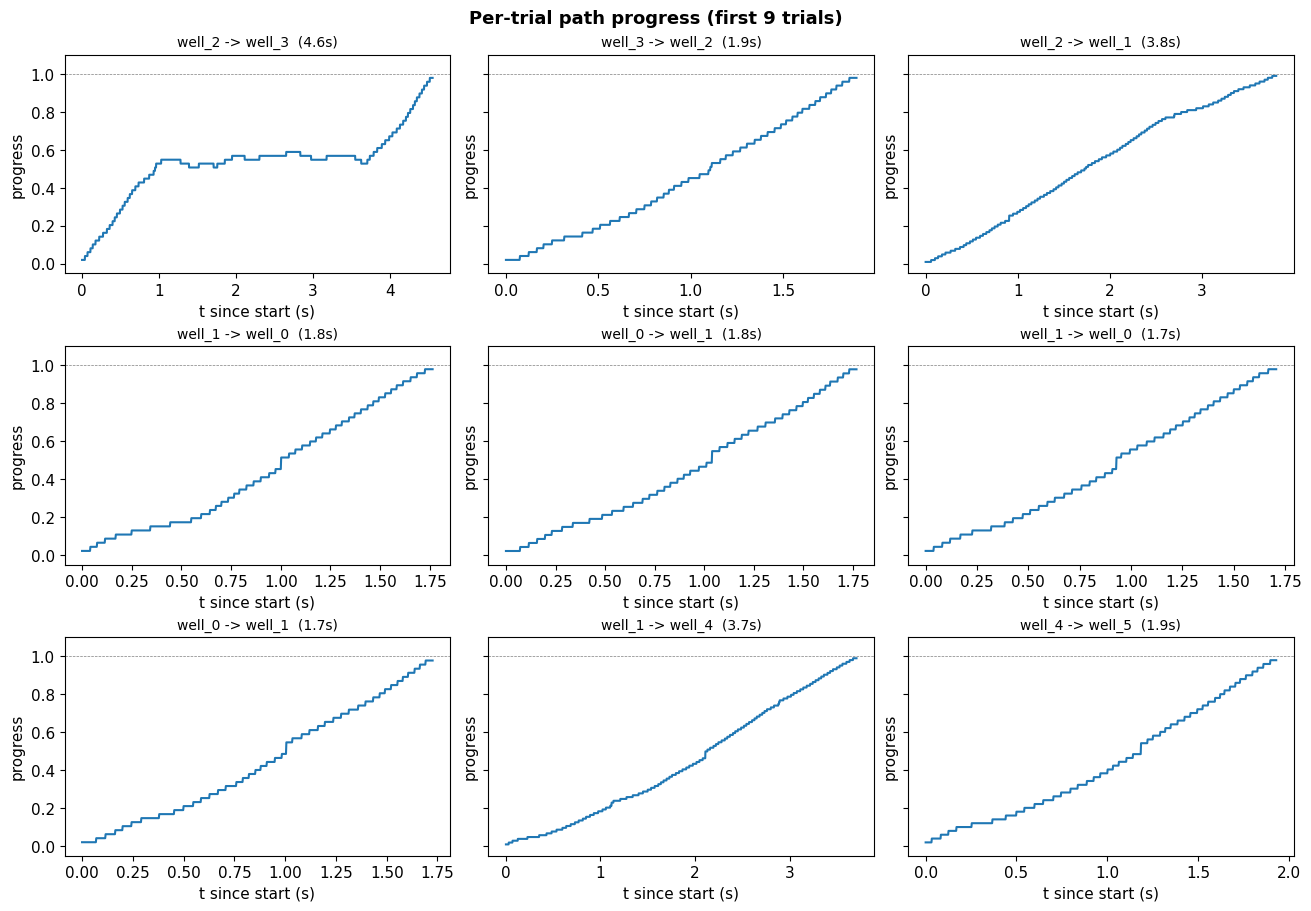

In [13]:
N_SHOW = 9
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharey=True, constrained_layout=True)
for ax, tr in zip(axes.flat, trials[:N_SHOW], strict=False):
    mask = (times >= tr["t0"]) & (times < tr["t1"])
    t = times[mask] - tr["t0"]
    p = progress[mask]
    ax.plot(t, p, color="tab:blue", lw=1.5)
    ax.axhline(1.0, color="tab:gray", lw=0.5, ls="--")
    ax.set_ylim(-0.05, 1.1)
    ax.set_title(f"{tr['start']} -> {tr['goal']}  ({t[-1]:.1f}s)", fontsize=10)
    ax.set_xlabel("t since start (s)")
    ax.set_ylabel("progress")
fig.suptitle("Per-trial path progress (first 9 trials)", fontsize=13, fontweight="bold")
plt.show()

## 8. Aggregate progress vs. normalized trial time

Resample each trial onto a common time axis `[0, 1]` and average across
trials. The expected shape is a sigmoid-ish ramp -- animals tend to
spend a fraction of trial time near the start (sniffing, consuming
reward) before committing to a directed run.

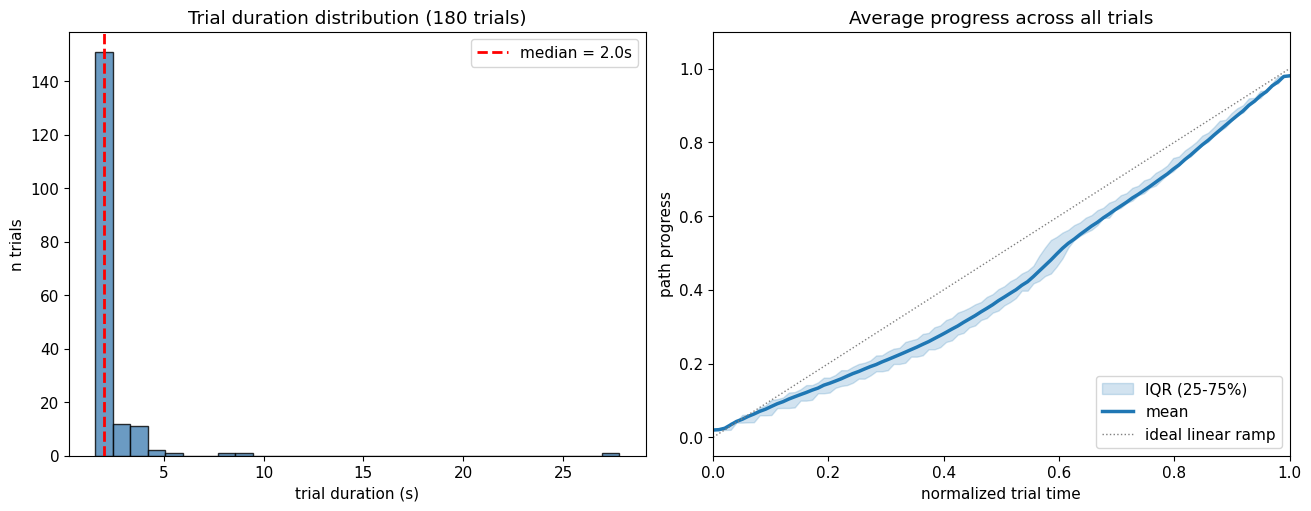

In [14]:
N_GRID = 100
t_norm = np.linspace(0.0, 1.0, N_GRID)
per_trial = np.full((len(trials), N_GRID), np.nan)

for i, tr in enumerate(trials):
    mask = (times >= tr["t0"]) & (times < tr["t1"])
    if mask.sum() < 2:
        continue
    t_local = (times[mask] - tr["t0"]) / max(tr["t1"] - tr["t0"], 1e-9)
    p = progress[mask]
    valid = ~np.isnan(p)
    if valid.sum() < 2:
        continue
    per_trial[i] = np.interp(t_norm, t_local[valid], p[valid])

mean_p = np.nanmean(per_trial, axis=0)
lo_p = np.nanpercentile(per_trial, 25, axis=0)
hi_p = np.nanpercentile(per_trial, 75, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
ax.hist(durations, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(
    np.median(durations),
    color="red",
    lw=2,
    ls="--",
    label=f"median = {np.median(durations):.1f}s",
)
ax.set_xlabel("trial duration (s)")
ax.set_ylabel("n trials")
ax.set_title(f"Trial duration distribution ({len(trials)} trials)")
ax.legend()

ax = axes[1]
ax.fill_between(t_norm, lo_p, hi_p, color="tab:blue", alpha=0.2, label="IQR (25-75%)")
ax.plot(t_norm, mean_p, color="tab:blue", lw=2.5, label="mean")
ax.plot([0, 1], [0, 1], color="tab:gray", lw=1, ls=":", label="ideal linear ramp")
ax.set_xlabel("normalized trial time")
ax.set_ylabel("path progress")
ax.set_title("Average progress across all trials")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.1)
ax.legend(loc="lower right")

plt.show()

## 9. Spatial view: one trial colored by progress

Plot one trial's 2D trajectory with each sample coloured by its
progress value. This makes the geodesic distance interpretation
concrete -- progress along the path, not Euclidean distance to goal.
The trajectory begins inside the start well (progress ~ 0) and ends
inside the goal well (progress ~ 1).

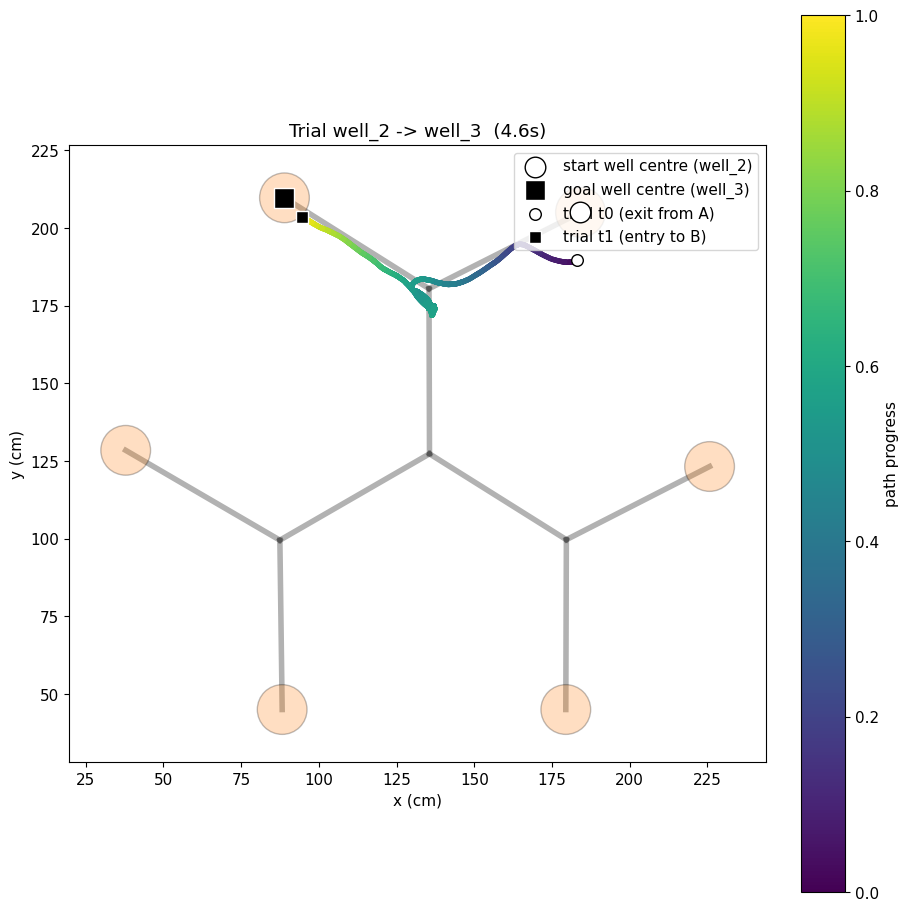

In [15]:
# Pick a representative trial: one with a clean, longer-than-median duration.
median_dur = float(np.median(durations))
clean_trials = [
    tr for tr in trials if median_dur < tr["t1"] - tr["t0"] < 3 * median_dur
]
demo_trial = clean_trials[0] if clean_trials else trials[0]
mask = (times >= demo_trial["t0"]) & (times < demo_trial["t1"])
xy = positions[mask]
p = progress[mask]

fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)

# Track edges
for u, v in track_graph.edges():
    pu = np.array(track_graph.nodes[u]["pos"])
    pv = np.array(track_graph.nodes[v]["pos"])
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], "k-", lw=4, alpha=0.3, zorder=1)

# Wells (faded) - drawn as circles at endpoint node positions
for n in endpoint_nodes:
    cx, cy = track_graph.nodes[n]["pos"]
    ax.add_patch(
        Circle(
            (cx, cy),
            well_radius_cm,
            facecolor="tab:orange",
            edgecolor="black",
            lw=1.0,
            alpha=0.25,
            zorder=2,
        )
    )

# Trajectory coloured by progress
sc = ax.scatter(
    xy[:, 0], xy[:, 1], c=p, cmap="viridis", vmin=0.0, vmax=1.0, s=8, zorder=5
)
ax.scatter(
    *xy[0],
    color="white",
    edgecolor="black",
    s=140,
    marker="o",
    linewidths=1.5,
    zorder=10,
    label=f"start ({demo_trial['start']})",
)
ax.scatter(
    *xy[-1],
    color="black",
    edgecolor="white",
    s=140,
    marker="s",
    linewidths=1.5,
    zorder=10,
    label=f"goal ({demo_trial['goal']})",
)

ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_title(
    f"Trial {demo_trial['start']} -> {demo_trial['goal']}  "
    f"({demo_trial['t1'] - demo_trial['t0']:.1f}s)"
)
plt.colorbar(sc, ax=ax, label="path progress")
ax.legend(loc="upper right")
plt.show()

## Summary

Recipe for goal-to-goal path progression on a track graph:

1. **Environment** from `track_graph` via `Environment.from_graph(...)`.
2. **Goal regions** from endpoint nodes via `env.regions.buffer(point, radius, name)`
   (must be polygons, not points).
3. **Detect entries** to each well with `detect_region_crossings(..., direction="entry")`
   and merge events chronologically.
4. **Pair consecutive visits** into trials; drop self-transitions.
5. **Build per-timepoint arrays** `start_bins[t]`, `goal_bins[t]` using a
   half-open mask `[t0, t1)` so adjacent trials don't collide at the
   boundary timestamp.
6. **Compute** `path_progress(position_bins, env, start_bins=..., goal_bins=...,
   metric="geodesic")`. Use geodesic on track graphs so distances respect
   the topology rather than cutting across the linearized 1D gaps.

`path_progress` reads start/goal *per timepoint*, so multi-well
shuttling, free choice, or task-cued goals are all just different ways
of populating the two arrays.

### See also

- `19_real_data_bandit_task.ipynb` - place-field analysis on this same dataset
- `14_behavioral_segmentation.ipynb` - alternative trial segmentation tools
- `path_progress` docstring (`src/neurospatial/behavior/navigation.py`)